## Bayes Theorem  
- Mathematical way to invert conditional probabilities
- $P(A|B) = \frac{P(A\cap{B})}{P(B)} = \frac{P(B|A)P(A)}{P(B)}$
- P(A|B) and P(B|A) are called conditional probabilities
- Let $f_k(X) = P(X | Y = k)$ denote the density function of X for an observation that comes from kth class then
  $P(Y = k | X = x) = \frac{P(Y = k, X = x)}{P(X = x)} = \frac{P(X = x | Y = k) P(Y = k)}{P(X = x)}$
  = $\frac{P(X = x | Y = k) P(Y = k)}{\Sigma^{K}_{l=1}P(X = x| Y = k)P(Y = k)}$ = $\frac{\pi_k f_k(x)}{\Sigma^{K}_{l = 1}\pi_l f_l(x)}$
- Pr(Y = k|X = x) is the posterior probability that an observation X = x belongs to the $k^{th}$ class and $\pi_k$ represent the overall or `prior probability` that a randomly chosen observation comes from the kth class
- To compute Pr(Y = k|X = x), we need to have estimates of $\pi_k$'s and $f_k$'s for k = 1, 2, ...., K
- Estimating the prior probabilities $\pi_1$, $\pi_2$, ..., $\pi_K$ is typically straightforward: for instance, we can estimate $\hat{\pi_k}$ as the proportion of training observations belonging to the kth class, for k = 1, . . . ,K.
- We assume that features are independent. Stated mathematically, this assumption means that for k = 1, . . . ,K,
  </br> $f_k(x) = f_{k1}(x_1) × f_{k2}(x_2)×· · ·×f_{kp}(x_p)$
  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv(r'PlayTennis.csv')
df

,Day,Outlook,Temprature,Humidity,Wind,Play_Tennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [3]:
print(pd.crosstab(df['Play_Tennis'], df['Outlook']))
print('\n', pd.crosstab(df['Play_Tennis'], df['Temprature']))
print('\n', pd.crosstab(df['Play_Tennis'], df['Humidity']))
print('\n', pd.crosstab(df['Play_Tennis'], df['Wind']))

Outlook      Overcast  Rain  Sunny
Play_Tennis                       
No                  0     2      3
Yes                 4     3      2

 Temprature   Cool  Hot  Mild
Play_Tennis                 
No              1    2     2
Yes             3    2     4

 Humidity     High  Normal
Play_Tennis              
No              4       1
Yes             3       6

 Wind         Strong  Weak
Play_Tennis              
No                3     2
Yes               3     6


- Find the `target` (Play_Tennis) when (Outlook = sunny, Temperature = cool, Humidity = high, Wind = strong)
- i.e. compute P(PlayTennis = Yes) and P(PlayTennis = No) and pick the target for which p is max
- What is k (number of classes in target variable) here?
- What is $\pi_1$ and $\pi_2$ ?
- $\pi_1$ = 9/14 and $\pi_2$ = 5/14
- P (Y = 1 | X = x) = $\frac{\pi_1 * f_1 (x)}{\pi_1 * f_1 (x) + \pi_2 * f_2 (x)}$
- Need to estimate $f_1 (x)$ and $f_2(x)$
- $f_1 (x)$ = $f_1$ (Outlook = sunny) x $f_1$ (Temperature = cool) x $f_1$ (Humidity = high) x $f_1$ (Wind = strong) ... due to condition on Naive Bayes  
- $f_1$ (Outlook = sunny) = P (Outlook = sunny | PlayTennis = 1 or Yes)  etc
- $\pi_1 f_1$ (x) = 9/14 * 2/9 * 3/9 * 3/9 * 3/9 = 0.00529
- $\pi_2 f_2$ (x) = 5/14 * 3/5 * 1/5 * 4/5 * 3/5 = 0.02057
- P (Play_Tennis = Yes|x) = 0.00529 / (0.00529 + 0.02057) = 0.205
- P (Play_Tennis = No|x) = 0.02057 / (0.00529 + 0.02057) = 0.795

### How do we estimate the density (probability)?   
- If $X_j$ is quantitative, we can assume that $X_j |Y = k \sim N(μ_{jk}, \sigma^2_{
jk})$.  In other words, we assume that within each class, the $j^{th}$ predictor is drawn from a (univariate) normal distribution
- If $X_j$ is quantitative, we can also use kernel-density method (non-parametric) approach
- If $X_j$ is qualitative, then we can simply count the proportion of training observations for the $j^{th}$ predictor corresponding to each class

In [4]:
df = pd.read_csv(r'Default.csv')
df['student'] = df['student'].factorize()[0]
df.head()

,default,student,balance,income
0,No,0,729.526495,44361.62507
1,No,1,817.180407,12106.13470
2,No,0,1073.549164,31767.13895
3,No,0,529.250605,35704.49394
4,No,0,785.655883,38463.49588


In [ ]:
## https://scikit-learn.org/1.5/modules/naive_bayes.html

In [ ]:
##Fit a naive bayes model on Default dataset
## compute accuracy and confusion matrix

In [ ]:
help(confusion_matrix)

## Evaluation Metrics
https://developers.google.com/machine-learning/crash-course/classification/thresholding  
- If logistic regression model predicts 0.5 (spam is positive) what does that mean? if prediction is 0.75?
- For real life use, we need to convert probability to either 0 or 1. We need `classification threshold` for this. If p is more than 'classification threshold' then response is positive class otherwise it is negative.
- For each model prediction there are 4 possibility. Below table captures these posibility in `confusion matrix`

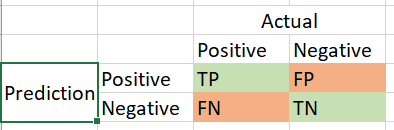  
- What is TP + FN and FP + TN?
- What is TP + FP and FN + TN?
- When the total of actual positives is not close to the total of actual negatives, the dataset is `imbalanced`
- If p increases, FN increases and FP decreases. Inverse is also true
- Accuracy = $\frac{TP + TN}{TP + FP + TN + FN}$
- when the dataset is imbalanced, or where one kind of mistake (FN or FP) is more costly than the other it is better to optimize for one of the other metrics
- What is model accuracy for a trivial model that predicts that customer will not default on `Default` dataset?
- Recall or (True Positive Rate - TPR) </br>
  Recall = $\frac{TP}{TP + FN}$ </br>
  Also called `detection rate`...........what proportion of positive's were identified correctly. This metric should be used for `Default` dataset
- Precision is the proportion of all the model's positive classifications that are actually positive </br>
    Precision = $\frac{TP}{TP + FP}$ </br>
    precision measures the fraction of emails classified as spam that were actually spam
- Precision and Recall are generally in inverse relation
- The F1 score is the harmonic mean (a kind of average) of precision and recall
  F1 = $\frac{2 * Precision * Recall}{Precision + Recall}$ </br>
  This metric balances the importance of precision and recall, and is preferable to accuracy for class-imbalanced datasets

In [ ]:
print(classification_report(df['default'], y_pred))

## LDA (Linear Discriminant Analysis)   
- If we assume that X's follow a multivariate Gaussian distribution (with a class-specific mean vector and a common variance matrix). then the model that we get is called LDA.
- With above assumption and some manipulation we get
  $δ_k(x) = x^TΣ^{−1}μ_k − \frac{1}{2}μ^{T}_kΣ^{−1}μ_k + log π_k$ </br>
  We assign class k for which $δ_k$ is the largest. $δ_k$ is also called the `discriminant` function and $δ_k$ is linear in x and hence the name LDA.
- If class has its own covariance matrix then we get `QDA (Quadratic Discriminant Analysis)`.

In [ ]:
## Implement LDA on Default dataset
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## Question 1  
Suppose that we wish to predict whether a given stock will issue a
dividend this year (“Yes” or “No”) based on X, last year’s percent
profit. We examine a large number of companies and discover that the
mean value of X for companies that issued a dividend was $\bar{X}$ = 10,
while the mean for those that didn’t was $\bar{X}$ = 0. In addition, the
variance of X for these two sets of companies was $\sigma^2$ = 36. Finally,
80 % of companies issued dividends. Assuming that X follows a normal
distribution, predict the probability that a company will issue
a dividend this year given that its percentage profit was X = 4 last
year.     


Hint: Recall that the density function for a normal random variable
is f(x) = $\frac{1}{\sqrt{2 \pi \sigma^2}} e^{-(x−μ)^2/2 \sigma^2}$ . You will need to use Bayes’ theorem.

- Target is `dividend issued` (Yes, No)
- P(Y = Yes | X = 4) ?
- $\pi_1$ = .80% and $\pi_2$ = .20%
- P(Y = Yes | X = 4) = $\frac{\pi_1 f_1(X=4)}{\pi_1 f_1(X=4) + \pi_2 f_2(X=4)}$
- What is $f_1$(X=4) and  $f_2$(X=4) ?
- $f_1$(X=4) = P(X=4 | Y=Yes) and $f_2$(X=4) = P(X=4 | Y=No)

In [12]:
from scipy.stats import norm
f1_x = norm.pdf(4, 10, 6)
f2_x = norm.pdf(4, 0, 6)

In [15]:
prob = .8 * f1_x / (.8 * f1_x + .2 * f2_x)
print(prob)

0.7518524532975261
